# Evaluation for the Multi-Agent Research Assistant

In [1]:
import sys
sys.version

'3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]'

## Importing the Necessary Libraries

In [2]:
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import nest_asyncio
from datasets import Dataset
from langchain_community.embeddings import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

from langchain_community.llms.fake import FakeListLLM
from ragas.llms import LangchainLLMWrapper
from langchain_core.language_models import BaseLanguageModel

# from ragas import evaluate
# from ragas.metrics import context_precision, context_recall
'''
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
'''

C:\Users\reign\anaconda3\envs\ragas_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


'\nfrom ragas.metrics import (\n    faithfulness,\n    answer_relevancy,\n    context_precision,\n    context_recall\n)\n'

In [3]:
# nest_asyncio.apply()

## Loading the Answer Dataset

In [4]:
with open("eval_dataset.json") as f:
    data = json.load(f)

In [5]:
# data[0]

## Evaluating using RAGAS

#### Creating Evaluation Dataset

In [6]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "llama3"

def call_llm(prompt):
    response = requests.post(
        OLLAMA_URL,
        json={
            "model": MODEL,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": 0   # deterministic output
            }
        }
    )

    return response.json()["response"]

In [7]:
def generate_ground_truth(question, contexts):
    prompt = f"""
You are a financial analyst.

Based ONLY on the context below, write a concise and correct answer.

Context:
{contexts}

Question:
{question}

Answer:
"""

    return call_llm(prompt)

In [8]:
for item in data:
    if not item["ground_truth"]:
        item["ground_truth"] = generate_ground_truth(
            item["question"],
            "\n".join(item["contexts"])
        )

#### Defining LLM and Embedding

In [13]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

#### Context Relevance <I>(Retrieval Quality)</I>

In [14]:
def context_relevance(question, contexts):
    q_emb = model.encode(question)
    ctx_embs = model.encode(contexts)
    
    sims = cosine_similarity([q_emb], ctx_embs)[0]
    return float(np.mean(sims))

#### Answer Relevance <I>(Answer vs Question)</I>

In [15]:
def answer_relevance(question, answer):
    q_emb = model.encode(question)
    a_emb = model.encode(answer)
    
    sim = cosine_similarity([q_emb], [a_emb])[0][0]
    return float(sim)

#### Groundedness <I>(Answer vs Context)</I>

In [16]:
def groundedness(answer, contexts):
    a_emb = model.encode(answer)
    ctx_embs = model.encode(contexts)
    
    sims = cosine_similarity([a_emb], ctx_embs)[0]
    return float(np.max(sims))  # best supporting chunk

## Evaluating both Systems

In [17]:
def evaluate_system(data, answer_key):
    results = []
    
    for item in data:
        q = item["question"]
        contexts = item["contexts"]
        ans = item[answer_key]
        
        results.append({
            "context_score": context_relevance(q, contexts),
            "answer_score": answer_relevance(q, ans),
            "groundedness": groundedness(ans, contexts)
        })
    
    return results

## Running Evaluation

In [18]:
rag_scores = evaluate_system(data, "rag_answer")
hybrid_scores = evaluate_system(data, "hybrid_answer")

## Comparing Results

In [19]:
def average_scores(scores):
    return {
        "context": np.mean([s["context_score"] for s in scores]),
        "answer": np.mean([s["answer_score"] for s in scores]),
        "groundedness": np.mean([s["groundedness"] for s in scores])
    }

In [20]:
rag_avg = average_scores(rag_scores)
hybrid_avg = average_scores(hybrid_scores)

print("RAG:", rag_avg)
print("HYBRID:", hybrid_avg)

RAG: {'context': 0.5534162521362305, 'answer': 0.4550086632370949, 'groundedness': 0.6128147393465042}
HYBRID: {'context': 0.5534162521362305, 'answer': 0.6795148700475693, 'groundedness': 0.6462686359882355}


#### Plotting the Results as Bar Plot

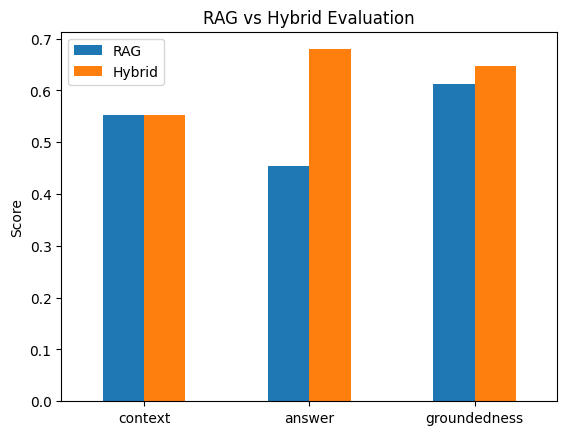

In [27]:
df.plot(kind="bar")
plt.title("RAG vs Hybrid Evaluation")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# THE END